# Predicting the United Rugby Championship

Can a simple rating model predict URC matches, and what does it miss?

This notebook walks through the data, the Elo model (Model A), what Elo gets wrong, the ML model that fixes it (Model B), and a Monte Carlo season simulation. All code lives in the `.py` modules; this notebook only loads results and tells the story.

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

import elo
from backtest import TEST_SEASON, TUNE_SEASONS, run, score

# one consistent style for every chart: thin marks, quiet grid, fixed colour order
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
INK, INK_2, AXIS, GRID, MUTED = "#0b0b0b", "#52514e", "#8a8984", "#e8e7e3", "#c3c2b7"
plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False, "axes.axisbelow": True,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "xtick.color": INK_2, "ytick.color": INK_2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.prop_cycle": plt.cycler(color=PALETTE),
    "lines.linewidth": 2, "font.size": 10,
})

history = pd.read_csv("data/history.csv", parse_dates=["date"])
backtest = pd.read_csv("data/elo_backtest.csv", parse_dates=["date"])
print(f"{len(history)} matches, {history.season.nunique()} seasons")

753 matches, 5 seasons


## 1. The data

753 URC matches from 2021/22 to 2025/26, scraped from Wikipedia. Before building anything: how often does the home team win?

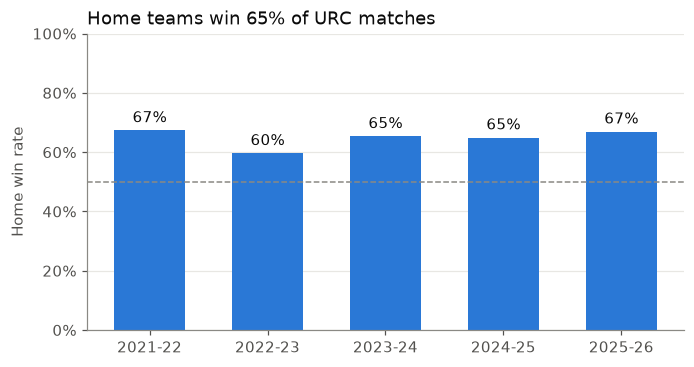

In [33]:
home_win = history.home_score > history.away_score
rate = home_win.groupby(history.season).mean()

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.bar(rate.index, rate.values, width=0.6, color=PALETTE[0])
ax.axhline(0.5, color=AXIS, lw=1, ls="--")
ax.bar_label(bars, labels=[f"{v:.0%}" for v in rate], padding=3, color=INK)
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_title(f"Home teams win {home_win.mean():.0%} of URC matches", loc="left")
ax.set_ylabel("Home win rate")
ax.grid(axis="x", visible=False)
plt.show()

Home advantage is large and stable across seasons. This sets the bar: "always pick the home team" already gets about 70% accuracy, so any model has to beat that to be worth anything.

## 2. Model A: Elo

Each team has one rating in points. After every match, both ratings move by K × (actual margin − predicted margin), which is online gradient descent on squared margin error.

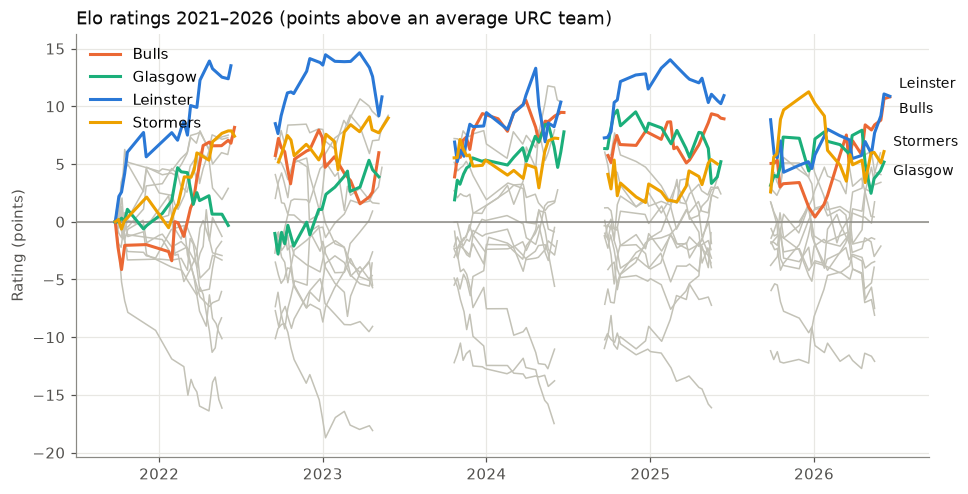

In [34]:
long = pd.concat([
    backtest[["date", "season", "home", "elo_home"]].set_axis(["date", "season", "team", "rating"], axis=1),
    backtest[["date", "season", "away", "elo_away"]].set_axis(["date", "season", "team", "rating"], axis=1),
]).sort_values("date")

HIGHLIGHT = ["Leinster", "Bulls", "Glasgow", "Stormers"]
LABEL_NUDGE = {"Leinster": 8, "Bulls": -8, "Glasgow": -6, "Stormers": 6}   # points, avoids overlapping end labels

fig, ax = plt.subplots(figsize=(10, 5))
for team, g in long.groupby("team"):
    color, width = (PALETTE[HIGHLIGHT.index(team)], 2) if team in HIGHLIGHT else (MUTED, 1)
    for i, (_, s) in enumerate(g.groupby("season")):          # one segment per season: no lines across the off-season
        ax.plot(s.date, s.rating, color=color, lw=width,
                label=team if (team in HIGHLIGHT and i == 0) else None,
                zorder=3 if team in HIGHLIGHT else 1)
    if team in HIGHLIGHT:
        ax.annotate(team, (g.date.iloc[-1], g.rating.iloc[-1]), xytext=(6, LABEL_NUDGE[team]),
                    textcoords="offset points", va="center", color=INK, fontsize=9)

ax.axhline(0, color=AXIS, lw=1)
ax.set_title("Elo ratings 2021–2026 (points above an average URC team)", loc="left")
ax.set_ylabel("Rating (points)")
ax.legend(loc="upper left", frameon=False)
plt.show()

Leinster have been the strongest URC side throughout, peaking ~14 points above average. The Bulls rose from below average in 2021/22 into the top tier, and Glasgow's climb in 2022/23 preceded their 2023/24 title. Ratings shrink toward zero each off-season (carry = 0.7), visible as the gap-and-drop at each season boundary.

## 3. Evaluating Elo

Elo's settings (K and home advantage) were chosen by grid search: replay 2022–2025 with every combination and keep the one with the lowest average margin error. 2025/26 was held out as a test season.

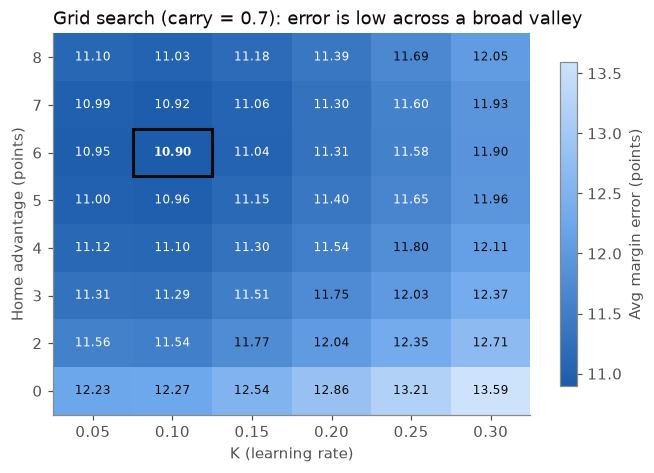

In [35]:
import itertools
from matplotlib.colors import LinearSegmentedColormap

matches = history.sort_values("date")
K_GRID = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
HFA_GRID = [0, 2, 3, 4, 5, 6, 7, 8]
CARRY = 0.7

mae = pd.DataFrame(index=HFA_GRID, columns=K_GRID, dtype=float)
for k, hfa in itertools.product(K_GRID, HFA_GRID):
    h = run(matches, {"k": k, "hfa": hfa}, CARRY)
    tune = h[h.season.isin(TUNE_SEASONS)]
    mae.loc[hfa, k] = (tune.actual_margin - tune.pred_margin).abs().mean()

BLUES = LinearSegmentedColormap.from_list("blues", ["#1c5cab", "#6da7ec", "#cde2fb"])   # dark = low error = good
fig, ax = plt.subplots(figsize=(7, 4.5))
im = ax.imshow(mae.values, cmap=BLUES, aspect="auto", origin="lower")
ax.set_xticks(range(len(K_GRID)), [f"{k:.2f}" for k in K_GRID])
ax.set_yticks(range(len(HFA_GRID)), HFA_GRID)
ax.set_xlabel("K (learning rate)")
ax.set_ylabel("Home advantage (points)")
ax.grid(False)

best_hfa, best_k = np.unravel_index(np.nanargmin(mae.values), mae.shape)
for i in range(mae.shape[0]):
    for j in range(mae.shape[1]):
        v = mae.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                color="white" if v < mae.values.mean() else INK,
                fontweight="bold" if (i, j) == (best_hfa, best_k) else "normal")
ax.add_patch(plt.Rectangle((best_k - 0.5, best_hfa - 0.5), 1, 1, fill=False, ec=INK, lw=2))
fig.colorbar(im, ax=ax, label="Avg margin error (points)", shrink=0.85)
ax.set_title(f"Grid search (carry = {CARRY}): error is low across a broad valley", loc="left")
plt.show()

In [36]:
from backtest import baseline

tuned = run(matches, {"k": 0.10, "hfa": 6}, 0.7)
tune = tuned[tuned.season.isin(TUNE_SEASONS)]
sigma = (tune.actual_margin - tune.pred_margin).std()
default = run(matches, {"k": 0.15, "hfa": 4.0}, 0.6)
test = tuned[tuned.season == TEST_SEASON]

report = pd.DataFrame({
    "Home always wins (baseline)": score(baseline(test), sigma),
    "Elo, default guesses": score(default[default.season == TEST_SEASON], 13.5),
    "Elo, tuned": score(test, sigma),
}).T.drop(columns="matches")
report.round(3)

,accuracy,brier,log_loss,margin_mae
Home always wins (baseline),0.701,0.202,0.618,13.567
"Elo, default guesses",0.701,0.182,0.568,12.762
"Elo, tuned",0.715,0.172,0.545,12.385


The error surface is a broad, flat valley: many nearby settings perform almost equally well, so the chosen values (K = 0.10, home advantage = 6) aren't fragile, and they're likely to hold up on new seasons.

On the held-out 2025/26 season, tuned Elo beats both baselines. Accuracy barely moves (home teams win 70% anyway), but the Brier score falls from 0.202 to 0.172. 

## 4. What Elo misses

Elo gives every home team the same 6-point advantage. But is home advantage really constant?

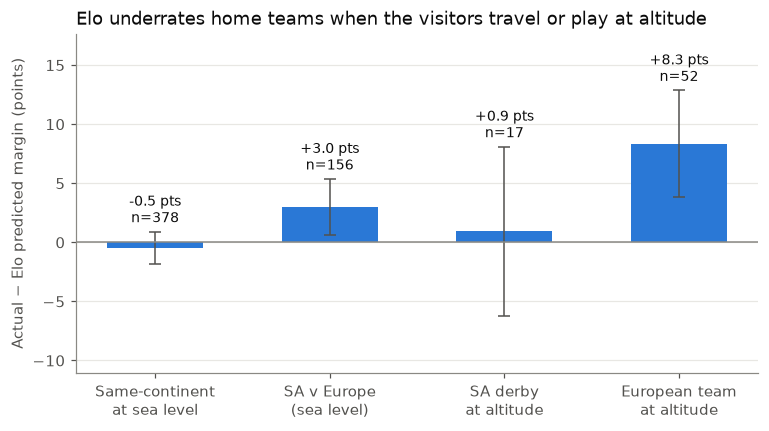

In [37]:
feats = pd.read_csv("data/features.csv", parse_dates=["date"])
d = feats.merge(backtest[["date", "home", "away", "pred_margin"]], on=["date", "home", "away"])
d = d[d.season != "2021-22"].copy()                 # skip Elo's warm-up season
d["elo_error"] = d.margin - d.pred_margin


def match_type(row):
    if row.altitude and row.cross_continent:
        return "European team\nat altitude"
    if row.altitude:
        return "SA derby\nat altitude"
    if row.cross_continent:
        return "SA v Europe\n(sea level)"
    return "Same-continent\nat sea level"


ORDER = ["Same-continent\nat sea level", "SA v Europe\n(sea level)", "SA derby\nat altitude", "European team\nat altitude"]
d["match_type"] = d.apply(match_type, axis=1)
g = d.groupby("match_type").elo_error.agg(["mean", "std", "count"]).reindex(ORDER).dropna()
g["ci"] = 1.96 * g["std"] / np.sqrt(g["count"])     # 95% confidence interval of the mean

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(g.index, g["mean"], width=0.55, color=PALETTE[0], yerr=g["ci"],
              error_kw={"ecolor": INK_2, "elinewidth": 1, "capsize": 4})
ax.axhline(0, color=AXIS, lw=1)
for bar, (_, r) in zip(bars, g.iterrows()):
    top = max(r["mean"] + r["ci"], 0)
    ax.text(bar.get_x() + bar.get_width() / 2, top + 0.4, f"{r['mean']:+.1f} pts\nn={int(r['count'])}",
            ha="center", va="bottom", fontsize=9, color=INK)
ax.set_ylabel("Actual − Elo predicted margin (points)")
ax.set_title("Elo underrates home teams when the visitors travel or play at altitude", loc="left")
ax.grid(axis="x", visible=False)
ax.margins(y=0.25)
plt.show()

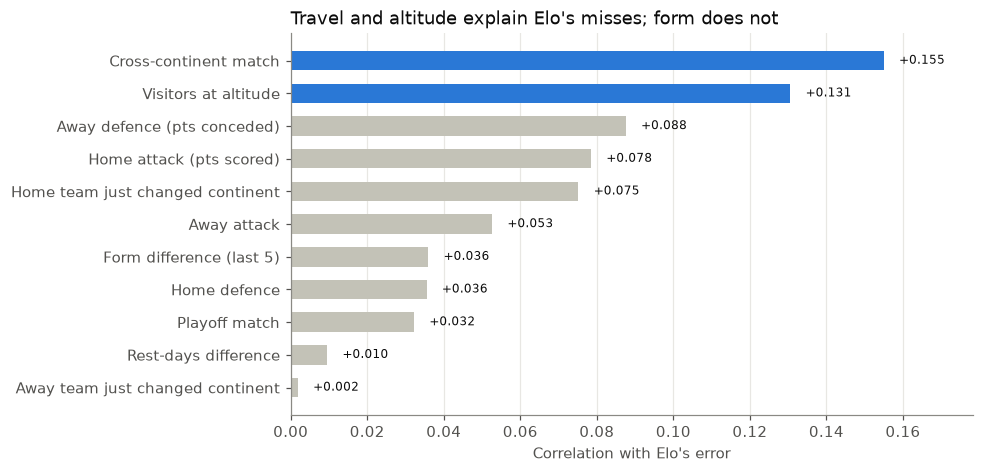

In [38]:
COLS = {"cross_continent": "Cross-continent match", "altitude": "Visitors at altitude",
        "away_defence": "Away defence (pts conceded)", "home_attack": "Home attack (pts scored)",
        "home_changed_continent": "Home team just changed continent", "away_attack": "Away attack",
        "form_diff": "Form difference (last 5)", "home_defence": "Home defence",
        "playoff": "Playoff match", "rest_diff": "Rest-days difference",
        "away_changed_continent": "Away team just changed continent"}

corr = d[list(COLS) + ["elo_error"]].corr()["elo_error"].drop("elo_error").rename(COLS).dropna()
corr = corr.reindex(corr.abs().sort_values().index)          # biggest at the top

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(corr.index, corr.values, height=0.6,
        color=[PALETTE[0] if n in ("Cross-continent match", "Visitors at altitude") else MUTED for n in corr.index])
ax.axvline(0, color=AXIS, lw=1)
for y, v in enumerate(corr.values):
    ax.text(v + (0.004 if v >= 0 else -0.004), y, f"{v:+.3f}", va="center",
            ha="left" if v >= 0 else "right", fontsize=8, color=INK)
ax.set_xlabel("Correlation with Elo's error")
ax.set_title("Travel and altitude explain Elo's misses; form does not", loc="left")
ax.grid(axis="y", visible=False)
ax.margins(x=0.15)
plt.show()

Home advantage is **not** constant. In same-continent matches at sea level, Elo's error averages close to zero: its flat 6-point home advantage is about right. But when a team crosses continents, and especially when a European side plays at altitude (Loftus, Ellis Park), the home team does several points better than Elo predicts, and the confidence intervals sit clearly above zero.

Form, attack and defence barely correlate with Elo's error. Elo already captures "how good is this team lately". What it can't see is **context**: travel and altitude. That's what Model B adds.

## 5. Model B: adding what Elo misses

Four models, all scored on the same held-out 2025/26 season:
- **Elo** (Model A)
- **Linear:** Elo difference + cross-continent + altitude (3 features)
- **Ridge:** all 12 features, regularised
- **Gradient boosting:** all 12 features, trees

In [39]:
from sklearn.model_selection import KFold, cross_val_predict
from model_b import MODELS, evaluate, load

train, test = load()
elo_sigma = (train.margin - train.elo_pred).std()
preds = {"Elo (Model A)": (test.elo_pred.values, elo_sigma)}

for name, (cols, model) in MODELS.items():
    oof = cross_val_predict(model, train[cols], train.margin, cv=KFold(5))
    sigma = (train.margin - oof).std()                 # honest sigma from out-of-fold errors
    model.fit(train[cols], train.margin)
    preds[name] = (model.predict(test[cols]), sigma)

comparison = pd.DataFrame({name: evaluate(p, test.margin, s) for name, (p, s) in preds.items()}).T
comparison.drop(columns="matches").round(3)

,accuracy,brier,log_loss,margin_mae
Elo (Model A),0.715,0.172,0.545,12.385
Linear (Elo + travel),0.708,0.167,0.529,12.049
Ridge (all features),0.750,0.167,0.530,12.045
Gradient boosting (all),0.743,0.171,0.539,12.650


### What the linear model learned

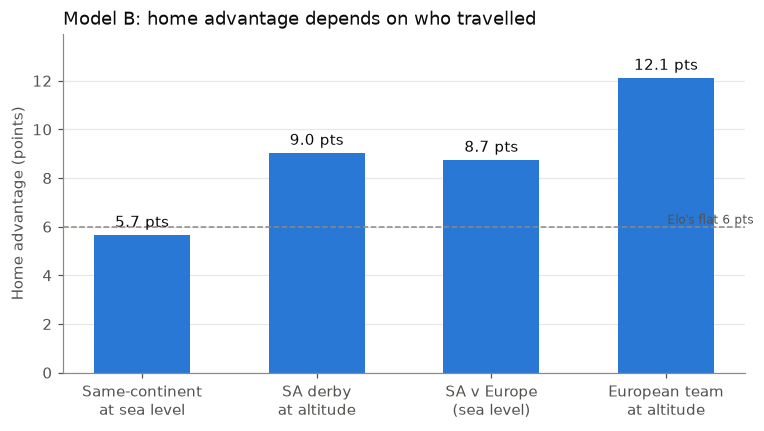

margin = 5.7 + 1.08*elo_diff + 3.09*cross_continent + 3.37*altitude


In [40]:
lin_cols, lin = MODELS["Linear (Elo + travel)"]
coef = dict(zip(lin_cols, lin.coef_))
base = lin.intercept_                                  # home advantage when nobody travelled

home_adv = pd.Series({
    "Same-continent\nat sea level": base,
    "SA derby\nat altitude": base + coef["altitude"],
    "SA v Europe\n(sea level)": base + coef["cross_continent"],
    "European team\nat altitude": base + coef["cross_continent"] + coef["altitude"],
})

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(home_adv.index, home_adv.values, width=0.55, color=PALETTE[0])
ax.bar_label(bars, labels=[f"{v:.1f} pts" for v in home_adv], padding=3, color=INK)
ax.axhline(6, color=AXIS, lw=1, ls="--")
ax.text(len(home_adv) - 0.5, 6, "Elo's flat 6 pts", va="bottom", ha="right", fontsize=8, color=INK_2)
ax.set_ylabel("Home advantage (points)")
ax.set_title("Model B: home advantage depends on who travelled", loc="left")
ax.grid(axis="x", visible=False)
ax.margins(y=0.15)
plt.show()

print(f"margin = {base:.1f} + {coef['elo_diff']:.2f}*elo_diff + "
      f"{coef['cross_continent']:.2f}*cross_continent + {coef['altitude']:.2f}*altitude")

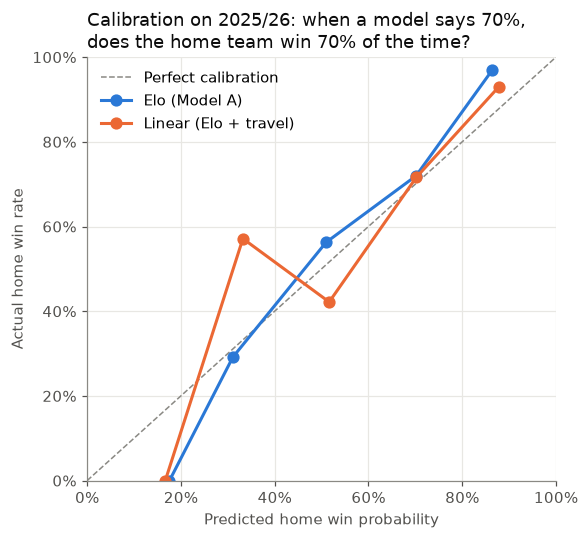

In [41]:
y = (np.sign(test.margin.values) + 1) / 2              # 1 home win / 0.5 draw / 0 away win
bins = np.linspace(0, 1, 6)                            # 5 buckets: 0-20%, 20-40%, ...

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot([0, 1], [0, 1], color=AXIS, lw=1, ls="--", label="Perfect calibration")
for color, name in zip(PALETTE, ["Elo (Model A)", "Linear (Elo + travel)"]):
    margin, sigma = preds[name]
    p = np.array([elo.win_prob(m, sigma) for m in margin])
    cal = pd.DataFrame({"p": p, "y": y, "bin": pd.cut(p, bins, include_lowest=True)})
    cal = cal.groupby("bin", observed=True).agg(p=("p", "mean"), y=("y", "mean"))
    ax.plot(cal.p, cal.y, marker="o", markersize=7, color=color, label=name)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlabel("Predicted home win probability")
ax.set_ylabel("Actual home win rate")
ax.set_title("Calibration on 2025/26: when a model says 70%,\ndoes the home team win 70% of the time?", loc="left")
ax.legend(frameon=False, loc="upper left")
plt.show()

Adding just two context features (cross-continent travel and altitude) to Elo improves every probability metric. **Linear and Ridge tie**, but Ridge's extra 9 features add nothing, so Linear was chosen for simplicity and interpretability. Gradient boosting does worse than both: with ~450 training matches, trees overfit.

The linear model's coefficients read directly as home advantage: ~6 points when nobody travels, rising to ~12 points when a European side plays at altitude in South Africa.

Both models are well calibrated: the points sit close to the diagonal, so a "70%" prediction really does come true about 70% of the time. That's what makes the probabilities usable, e.g. for comparing against bookmaker odds.

## 6. Is the improvement real?

Model B beat Elo on 151 test matches, but some of that could be luck. A **paired bootstrap** resamples the test season 10,000 times (random matches, with replacement) and re-scores both models on each resample. If Model B still wins in almost every resampled season, the improvement is real.

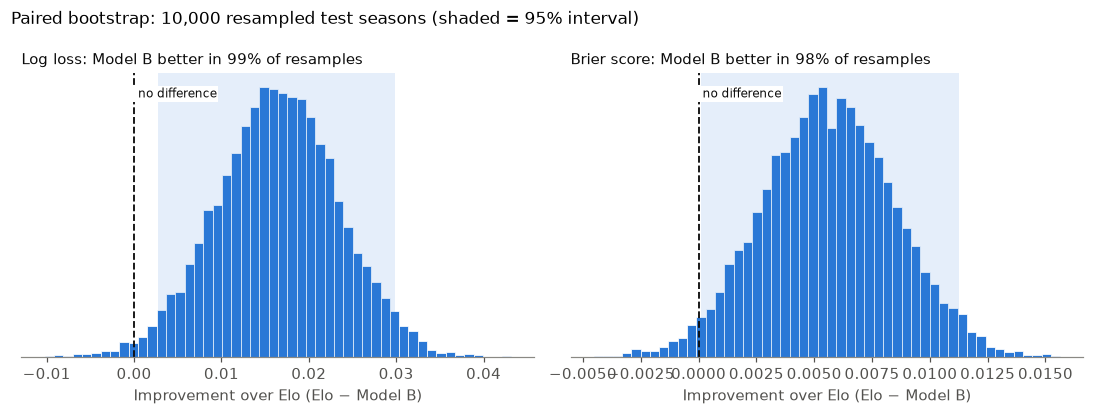

In [42]:
from bootstrap import N_BOOT, per_match_losses

rng = np.random.default_rng(42)
actual = test.margin.values
elo_loss = per_match_losses(*preds["Elo (Model A)"][:1], actual, preds["Elo (Model A)"][1])
b_loss = per_match_losses(*preds["Linear (Elo + travel)"][:1], actual, preds["Linear (Elo + travel)"][1])
idx = rng.integers(0, len(actual), size=(N_BOOT, len(actual)))     # each row = one resampled season

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for ax, (metric, label) in zip(axes, [("log_loss", "Log loss"), ("brier", "Brier score")]):
    diff = elo_loss[metric] - b_loss[metric]                        # positive = Model B better
    boot = diff[idx].mean(axis=1)
    lo, hi = np.percentile(boot, [2.5, 97.5])

    ax.hist(boot, bins=50, color=PALETTE[0], edgecolor="white", linewidth=0.5)
    ax.axvspan(lo, hi, color=PALETTE[0], alpha=0.12, lw=0)
    ax.axvline(0, color=INK, lw=1.2, ls="--")
    ax.text(0, ax.get_ylim()[1] * 0.95, " no difference", fontsize=8, color=INK, va="top",
            bbox={"fc": "white", "ec": "none", "pad": 1})
    ax.set_title(f"{label}: Model B better in {(boot > 0).mean():.0%} of resamples", loc="left", fontsize=10)
    ax.set_xlabel("Improvement over Elo (Elo − Model B)")
    ax.grid(axis="x", visible=False)
    ax.set_yticks([])
    ax.spines["left"].set_visible(False)

fig.suptitle("Paired bootstrap: 10,000 resampled test seasons (shaded = 95% interval)", x=0.01, ha="left", fontsize=11)
fig.tight_layout()
plt.show()

Almost the entire distribution sits to the right of zero: Model B beats Elo in ~99% of resampled seasons on log loss and ~98% on Brier. The improvement is modest in size but very unlikely to be luck.

The clearest gain is in log loss, which punishes confident wrong predictions most. Elo was overconfident in travelling teams and teams visiting altitude, and Model B corrects exactly that.

**Caveat:** the features and the final model were chosen after looking at data that included the test season, so this test isn't perfectly out-of-sample. The live 2026/27 season is the true confirmation.

## 7. Season simulation

Model B plays out the whole 2026/27 season 10,000 times. For each game it draws a random margin around its prediction (σ ≈ 14 points) and applies URC points (4 win, 2 draw, 1 losing bonus). Then it ranks the table and plays the playoffs (1v8, 2v7, 3v6, 4v5, higher seed at home). Counting outcomes gives each team's odds.

These are **pre-season** odds, from `simulate.py` before Round 1.

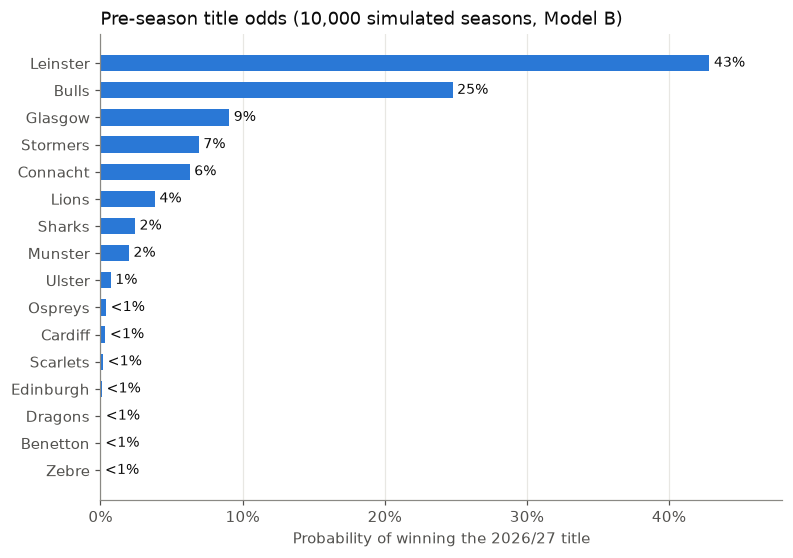

In [43]:
odds = pd.read_csv("data/season_odds_preseason.csv", index_col=0).sort_values("champion")

fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.barh(odds.index, odds.champion, height=0.6, color=PALETTE[0])
ax.bar_label(bars, labels=[f"{v:.0%}" if v >= 0.005 else "<1%" for v in odds.champion],
             padding=3, color=INK, fontsize=9)
ax.xaxis.set_major_formatter(PercentFormatter(1, decimals=0))
ax.set_xlabel("Probability of winning the 2026/27 title")
ax.set_title("Pre-season title odds (10,000 simulated seasons, Model B)", loc="left")
ax.grid(axis="y", visible=False)
ax.margins(x=0.12)
plt.show()

In [44]:
table = odds.sort_values("champion", ascending=False).copy()
table["exp_points"] = table["exp_points"].round(1)
for col in ["top_8", "top_4", "1st", "champion"]:
    table[col] = [f"{v:.0%}" if v >= 0.005 else "<1%" for v in table[col]]
table.columns = ["Exp. points", "Top 8", "Top 4", "1st", "Champion"]
table

,Exp. points,Top 8,Top 4,1st,Champion
Leinster,54.6,99%,91%,52%,43%
Bulls,50.1,96%,75%,20%,25%
Glasgow,47.0,89%,57%,10%,9%
Stormers,44.1,80%,39%,4%,7%
Connacht,44.3,79%,40%,6%,6%
Lions,41.9,69%,26%,2%,4%
Sharks,40.3,59%,21%,2%,2%
Munster,39.5,55%,18%,2%,2%
Ulster,37.2,41%,10%,1%,1%
Ospreys,35.8,34%,8%,1%,<1%


Leinster start as clear favourites (~43%), with the Bulls second (~25%). The Bulls benefit from the altitude effect: as a likely top-4 side they'd host playoff games at Loftus, where Model B gives them ~12 points of home advantage against European visitors.

Even the favourite is below 50%. With about 14 points of randomness per game plus three knockout rounds, a lot can happen. The odds tighten as the season goes on, because played games are fixed and only the remaining fixtures are simulated.

## 8. Limitations

- **Small test set.** 151 matches is enough to detect Model B's improvement (bootstrap ~98%), but not to measure its exact size precisely.
- **Mild selection bias.** Features and the final model were chosen after looking at data that included the test season. The live 2026/27 season is the true out-of-sample test.
- **No team news.** Neither model knows about injuries, rotation or international call-ups. URC sides, especially Irish ones, lose many players during international windows, which likely explains some of Elo's mid-season dips for Leinster.
- **Margins only, no tries.** The try bonus point isn't modelled, so simulated league points run a little lower than real totals.
- **Fixed strengths within each simulated season.** A team's rating doesn't change during a simulated season, so streaks aren't modelled.
- **One data source.** All results come from Wikipedia. They were checked against date ranges, but not against an official feed.

## Conclusion

1. **Elo works.** A one-number-per-team model, tuned by grid search, clearly beats the "home team always wins" baseline on probability quality (Brier 0.202 → 0.172), even though accuracy barely moves in a league where home teams win 70% of the time.
2. **Home advantage isn't constant.** Elo's errors show it underrates home teams when the visitors cross continents or play at altitude.
3. **Two context features fix most of that.** A 3-feature linear model (Elo + travel + altitude) beats Elo on every probability metric, ties a 12-feature Ridge model, and beats gradient boosting. The improvement holds in ~98–99% of bootstrap resamples.
4. **The simplest model that works was chosen,** and it's predicting the 2026/27 season live, with every prediction committed to git before kickoff.


## 9. Live 2026/27 season

The real out-of-sample test. Before every round, both models' predictions were committed to git (see `data/predictions_log.csv`), so they can't have been adjusted after the results. This section updates automatically as results are entered.

In [45]:
log = pd.read_csv("data/predictions_log.csv")
results = pd.read_csv("data/results.csv")
live = log.merge(results[["round", "home", "away", "home_score", "away_score"]], on=["round", "home", "away"])
live["margin"] = live.home_score - live.away_score


def live_score(p, pred_margin, margin):
    """Score logged pre-match probabilities against what happened."""
    y = (np.sign(margin) + 1) / 2
    p = np.clip(p, 1e-6, 1 - 1e-6)
    decided = margin != 0
    return {
        "matches": len(margin),
        "accuracy": (np.sign(pred_margin[decided]) == np.sign(margin[decided])).mean(),
        "brier": ((p - y) ** 2).mean(),
        "log_loss": -(y * np.log(p) + (1 - y) * np.log(1 - p)).mean(),
        "margin_mae": np.abs(margin - pred_margin).mean(),
    }


if live.empty:
    print("No 2026/27 results entered yet - this table fills in as the season is played.")
else:
    bookie_p = live.bookie_home_margin.apply(lambda m: elo.win_prob(m, elo.SIGMA))
    scoreboard = pd.DataFrame({
        "Elo (Model A)": live_score(live.elo_p_home, live.elo_margin, live.margin),
        "Model B": live_score(live.b_p_home, live.b_margin, live.margin),
        "Bookmaker line": live_score(bookie_p, live.bookie_home_margin, live.margin),
    }).T
    print(f"After round {live['round'].max()}:")
    display(scoreboard.round(3))

No 2026/27 results entered yet - this table fills in as the season is played.


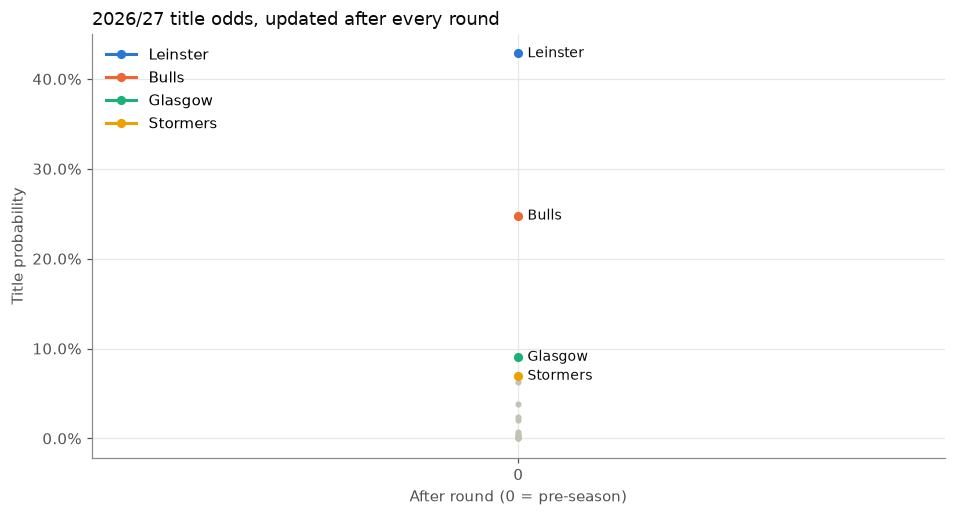

In [46]:
odds_hist = pd.read_csv("data/odds_history.csv")
latest = odds_hist[odds_hist.after_round == odds_hist.after_round.max()]
top = latest.nlargest(4, "champion").team.tolist()          # colour the current top 4

fig, ax = plt.subplots(figsize=(10, 5))
for team, g in odds_hist.sort_values("after_round").groupby("team"):
    if team not in top:
        ax.plot(g.after_round, g.champion, color=MUTED, lw=1, marker="o", markersize=3)
for color, team in zip(PALETTE, top):
    g = odds_hist[odds_hist.team == team].sort_values("after_round")
    ax.plot(g.after_round, g.champion, color=color, lw=2, marker="o", markersize=5, label=team)
    ax.annotate(team, (g.after_round.iloc[-1], g.champion.iloc[-1]), xytext=(6, 0),
                textcoords="offset points", va="center", color=INK, fontsize=9)

ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlabel("After round (0 = pre-season)")
ax.set_ylabel("Title probability")
ax.set_xticks(sorted(odds_hist.after_round.unique()))
ax.set_title("2026/27 title odds, updated after every round", loc="left")
ax.legend(frameon=False, loc="upper left")
ax.margins(x=0.08)
plt.show()

*To be written at the end of the season:*
- Did Model B beat Elo on the live season, as the 2025/26 test suggested?
- How close did either model get to the bookmakers?
- How did the title odds evolve, and which results moved them most?